### Phase 1: Data Loading & Exploration

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [20]:
#nltk.download('stopwords')
#nltk.download('punkt')
#nltk.download('wordnet')

In [21]:
df = pd.read_csv(r'C:\Users\faraz\Downloads\label.csv')

In [22]:
df.head()

,tweet_id,safe_text,label,agreement
0,CL1KWCMY,Me &amp; The Big Homie meanboy3000 #MEANBOY #M...,0.0,1.0
1,E3303EME,I'm 100% thinking of devoting my career to pro...,1.0,1.0
2,M4IVFSMS,"#whatcausesautism VACCINES, DO NOT VACCINATE Y...",-1.0,1.0
3,1DR6ROZ4,I mean if they immunize my kid with something ...,-1.0,1.0
4,J77ENIIE,Thanks to <user> Catch me performing at La Nui...,0.0,1.0


In [23]:
print(df['safe_text'].value_counts())

safe_text
<user> #GOP STOP blaming #Immigrants first #Ebola now #measles Which diseases?brought their ancestors? #AINF <url>                   32
Study of more than 95,000 kids finds no link between MMR vaccine and autism <url>                                                    18
Another Study Finds No Link Between MMR Vaccine and Autism <url>                                                                     17
Children's Museum of Houston to Offer Free Vaccinations <url>                                                                        15
“<user> On average, people who complain live longer -- Releasing this tension increases immunity and boosts their health.” <user>    15
                                                                                                                                     ..
<user> if you win a lot your mmr will even out, u suck tho                                                                            1
<user> “<user> Vaccinate your fucking 

In [24]:
df = df[['safe_text', 'label']].dropna()

In [25]:
label_map = {1.0: 'Positive', 0.0: 'Neutral', -1.0: 'Negative'}
df['sentiment'] = df['label'].map(label_map)

In [26]:
print("Sentiment Counts:\n", df['sentiment'].value_counts())

Sentiment Counts:
 sentiment
Neutral     4908
Positive    4053
Negative    1038
Name: count, dtype: int64


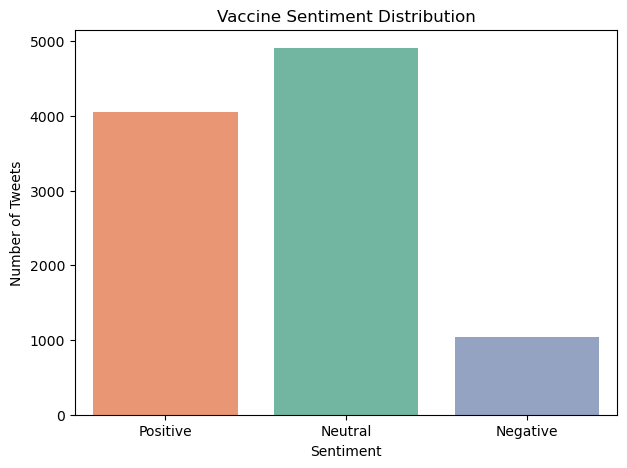

In [27]:
plt.figure(figsize=(7, 5))
sns.countplot(
    x='sentiment',
    data=df,
    order=['Positive', 'Neutral', 'Negative'],
    hue='sentiment',
    palette='Set2',
    legend=False
)

plt.title('Vaccine Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

### Phase 2: Text Preprocessing Pipeline

In [28]:
import string
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

def preprocess_tweet(text):
    if not isinstance(text, str):
        return ""

In [38]:
#import nltk

#nltk.download('punkt_tab')
#nltk.download('punkt')
#nltk.download('stopwords')
#nltk.download('wordnet')

In [39]:
def preprocess_tweet(text):
    text = re.sub(r'&amp;', 'and', text)
    text = re.sub(r'<user>', '', text)

    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))

    tokens = word_tokenize(text)

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(cleaned_tokens)

In [40]:
df['cleaned_text'] = df['safe_text'].apply(preprocess_tweet)
print(df[['safe_text', 'cleaned_text']].head())

                                           safe_text  \
0  Me &amp; The Big Homie meanboy3000 #MEANBOY #M...   
1  I'm 100% thinking of devoting my career to pro...   
2  #whatcausesautism VACCINES, DO NOT VACCINATE Y...   
3  I mean if they immunize my kid with something ...   
4  Thanks to <user> Catch me performing at La Nui...   

                                        cleaned_text  
0  big homie meanboy3000 meanboy mb mb mmr stegma...  
1  im 100 thinking devoting career proving autism...  
2           whatcausesautism vaccine vaccinate child  
3  mean immunize kid something wont secretly kill...  
4  thanks catch performing la nuit nyc 1134 1st a...  


### Phase 3: Train/Test Split & TF-IDF Extraction

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [51]:
print(df['cleaned_text'].isna().sum())
print(df['sentiment'].isna().sum())

0
0


In [52]:
print(df[['cleaned_text', 'sentiment']].isna().sum())

cleaned_text    0
sentiment       0
dtype: int64


In [53]:
df = df.dropna(subset=['cleaned_text', 'sentiment'])

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df['sentiment'],
    test_size=0.20,
    random_state=42,
    stratify=df['sentiment']
)

In [55]:
tfidf = TfidfVectorizer(max_features=5000) 
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

### Phase 4: Model Training & Evaluation

In [56]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [57]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}


==================== Naive Bayes ====================
Accuracy: 0.7015

              precision    recall  f1-score   support

    Negative       0.70      0.03      0.06       207
     Neutral       0.77      0.77      0.77       982
    Positive       0.64      0.78      0.70       811

    accuracy                           0.70      2000
   macro avg       0.70      0.53      0.51      2000
weighted avg       0.71      0.70      0.67      2000



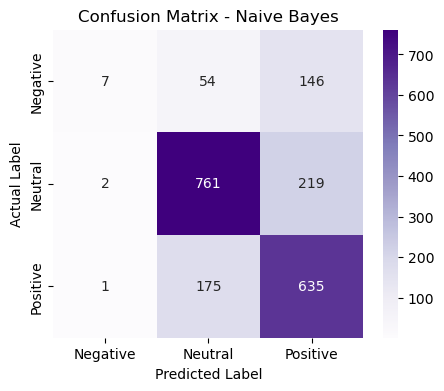


==================== Logistic Regression ====================
Accuracy: 0.7325

              precision    recall  f1-score   support

    Negative       0.67      0.22      0.33       207
     Neutral       0.78      0.81      0.79       982
    Positive       0.69      0.77      0.73       811

    accuracy                           0.73      2000
   macro avg       0.71      0.60      0.62      2000
weighted avg       0.73      0.73      0.72      2000



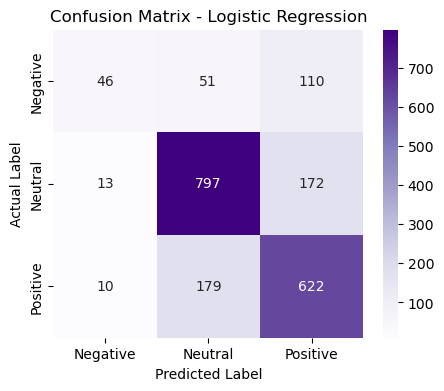

In [58]:
all_predictions = {}

for name, model in models.items():
    print(f"\n==================== {name} ====================")
    # Model Training
    model.fit(X_train_tfidf, y_train)
    
    # Predictions
    preds = model.predict(X_test_tfidf)
    all_predictions[name] = preds
    
    # Evaluation Metrics
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}\n")
    print(classification_report(y_test, preds))
    
    # Confusion Matrix Visualisation
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Purples',
                xticklabels=['Negative', 'Neutral', 'Positive'], 
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

### Phase 5: Error Analysis

In [59]:
error_df = pd.DataFrame({
    'Original_Tweet': df.loc[X_test.index, 'safe_text'],
    'Actual': y_test,
    'Predicted': all_predictions['Logistic Regression']
})

In [60]:
misclassified = error_df[error_df['Actual'] != error_df['Predicted']]

print("--- 5 Examples of Misclassified Tweets ---")
for idx, row in misclassified.head(5).iterrows():
    print(f"Tweet: {row['Original_Tweet']}")
    print(f"Actual Sentiment: {row['Actual']} | Predicted: {row['Predicted']}")
    print("-" * 50)

--- 5 Examples of Misclassified Tweets ---
Tweet: Meeting tonight, 8:30pm in room 322 of the student center! 💙💉 #kent #ksu kentstate #immunizations #ChildrenFirst <url>
Actual Sentiment: Positive | Predicted: Neutral
--------------------------------------------------
Tweet: I had to pay $70 for stupid immunization FUCK YOU Health services, they take forever and still rip me off with something I didn't nee..
Actual Sentiment: Negative | Predicted: Positive
--------------------------------------------------
Tweet: <user> <user>  vaccinations 4 babies starts it all up
Actual Sentiment: Negative | Predicted: Positive
--------------------------------------------------
Tweet: “<user> Vaccines are NOT safe. I call bullshit. <url>
Actual Sentiment: Negative | Predicted: Positive
--------------------------------------------------
Tweet: Warning about possible measles exposure in Seattle, Kirkland, Mercer Island: SEATTLE — Public health officials on... <url>
Actual Sentiment: Positive | Predicte

# Conclusion: Which Model Performed Best?

In this sentiment analysis task, we evaluated two distinct classification approaches: **Multinomial Naive Bayes** (a probabilistic classifier) and **Logistic Regression** (a linear classifier).

Based on the evaluation metrics from the classification reports, **Logistic Regression outperformed Naive Bayes**. The reasons for this performance difference include:

### 1. Handling of Sparse TF-IDF Vectors

Text data transformed by TF-IDF results in high-dimensional, sparse matrices. Logistic Regression is highly effective at finding the optimal decision boundary by assigning precise weights to these features.

### 2. Feature Interdependence

Naive Bayes operates on the strict assumption that all words (features) are completely independent of one another. In natural language, words heavily depend on context and surrounding terms. Logistic Regression handles these subtle correlations much better.

### 3. Mitigating Class Imbalance

Twitter datasets often contain a higher volume of positive or neutral tweets than negative ones. Naive Bayes tends to over-classify toward the majority class, whereas Logistic Regression utilizes L2 regularization by default, helping it achieve a more balanced F1-score across all three classes.

**Note:** Replace the placeholder values below with your actual results:

> Logistic Regression achieved a final accuracy of **X%** and a macro F1-score of **Y%**, compared to Naive Bayes, which achieved **A%** accuracy and a macro F1-score of **B%**.

# Real-World Applications

A sentiment analysis pipeline specialized in healthcare and vaccine discourse has significant value across multiple real-world domains.

## 1. Public Health Monitoring and Intervention

Government agencies and organizations such as the World Health Organization (WHO) can use this model to monitor live social media discussions. By identifying geographic increases in negative sentiment, public health officials can detect growing vaccine hesitancy and launch targeted awareness campaigns.

## 2. Misinformation Tracking and Early Warning Systems

If public sentiment toward a vaccine or medical trial suddenly declines, the system can serve as an early warning mechanism. Healthcare authorities can investigate the keywords and topics driving the shift and respond to misinformation, conspiracy theories, or public misconceptions before they spread widely.

## 3. Pharmaceutical Market Research

Pharmaceutical companies can use sentiment analysis to understand public perception of their products. Insights regarding effectiveness, accessibility, and side effects can support data-driven decisions in communication strategies and future research initiatives.

## 4. Automated Support Routing in Healthcare

The model can be integrated into healthcare support platforms and medical chatbots. When highly negative or distressed messages are detected, the system can automatically escalate the conversation to a healthcare professional instead of relying solely on automated responses.
